# Regresyon & OLS

**Regresyon**

* Regresyon analizi, bir ya da daha fazla bağımsız değişken (predictor / feature / X’ler) kullanarak, bir bağımlı değişkeni (target / Y) modellemeyi sağlayan bir tekniktir. Amaç — bağımsız değişkenler ile hedef değişken arasındaki ilişkiyi nicel olarak ifade eden bir “denklem” bulmaktır.
* Basit doğrusal regresyonda bu denklem genelde şöyle yazılır:
   - $\hat{y} = \hat{\beta}_{0} + \hat{\beta}_{1} x + ε$
   - $\hat{\beta}_{0}$ : sabit terim (intercept)
   - $\hat{\beta}_{1} x$ : x’in y üzerindeki etkisini gösteren katsayı (slope)
* ε ise hata / residual terimidir — “modelin açıklayamadığı / rastgele kısmı” (noise, gözlem hatası vb) .
* Çoklu regresyonda — bir bağımlı değişken (Y) ve birden fazla bağımsız değişken (X₁, X₂, …, Xₚ) varsa — model şu genel denklem ile ifade edilir:
  - $\hat{y} = \hat{\beta}_{0} + \hat{\beta}_{1}x_{1} + \hat{\beta}_{2}x_{2} + \dots + \hat{\beta}_{p}x_{p} + ε$
  - y: bağımlı değişken (tahmin etmek istediğimiz değişken)
  - $X_{1},X_{2},...,X_{p}$ : bağımsız değişkenler / özellikler / predictor’lar
  - $\hat{\beta}_{0}$ : intercept / sabit terim — tüm X’ler 0 iken Y’nin alacağı beklenen değer
  - $\hat{\beta}_{1},\hat{\beta}_{2},...,\hat{\beta}_{p}$ : her bir X’in Y üzerindeki “katsayı”sı — diğer değişkenler sabitken, o değişkende bir birimlik değişim olursa Y’de beklenen değişim miktarı
  - ε: hata / residual / “modelin açıklayamadığı / rastgele kısmı” (noise, gözlem hatası vb)

**OLS Regresyon Nedir?**
*OLS = Ordinary Least Squares = En Küçük Kareler Yöntemi*, doğrusal regresyonun katsayılarını bulmak için kullanılan matematiksel yöntemdir.

**Ordinary Least Squares (OLS) Regresyon Varsayımları**

1. **Modelin parametrelerine göre lineer olması**
   - Model denklemi, $\hat{y} = \hat{\beta}_{0} + \hat{\beta}_{1}x_{1} + \hat{\beta}_{2}x_{2} + \dots + \hat{\beta}_{p}x_{p} + ε$ biçiminde olmalı, yani katsayılarla lineer bir yapı içermeli.
   - X’lerin dönüşüm vb ile değil, parametrik katsayılarla çarpılan değişkenler olması
   | Model                                   | OLS için uygun mu? | Neden          |
| --------------------------------------- | ------------------ | -------------- |
| $(Y = \beta_0 + \beta_1 X)$               | ✔                  | β lineer       |
| $(Y = \beta_0 + \beta_1 X^2)$             | ✔                  | β lineer       |
| $(Y = \beta_0 + \beta_1 \ln(X))$          | ✔                  | β lineer       |
| $(Y = \beta_0 + \beta_1 X + \beta_2 X^2)$ | ✔                  | β lineer       |
| $(Y = X^{\beta_1})$                       | ❌                  | β lineer değil |
| $(Y = e^{\beta_1 X})$                     | ❌                  | β lineer değil |
| $(Y = \sin(\beta_1 X))$                   | ❌                  | β lineer değil |

2. **Hata (residual / error) terimlerinin beklenen değeri 0**
   - Yani E[ε]=0 Bu, modelin – ortalamada – tahmin hatasının sıfır olmasını garantiler.
   - Bu varsayım, sabit terim (intercept) eklendiğinde genelde sağlanabilir.
3. **Hata terimleri ile bağımsız değişkenler arasında ilişki / korelasyon olmaması (Exogeneity)**
   - Yani, X’ler hata terimi ile ilişkisiz olmalı; hata terimleri, gözlemler bağımsız olarak dağılmış olmalı.
   - Eğer bu ihlal edilirse — örneğin ölçüm hatası, omitted variable bias, endojenlik vs varsa — β katsayılarının tahminleri yanlı olabilir.
4. **Homoskedastisite — Hataların sabit varyanslı olması**
   - Tüm gözlemler için residual’ların varyansı aynı / sabit olmalı. Hata değişkenliği (variance) değişkenlere göre artıp azalmamalı.
   - Eğer varyans sabit değilse (heteroskedasticity), standart hata / güven aralığı & test sonuçları güvenilmez olur.
5. **Hata terimleri birbirinden bağımsız olmalı — serial correlation / autocorrelation olmamalı**
   - Özellikle zaman serisi ya da ardışık verilerde, residual’lar arasında korelasyon olmamalı. Bu, modelin yapısını ve tahmin gücünü bozar.
6. **Bağımsız değişkenler arasında multicollinearity (çoklu doğrusal bağlılık) olmamalı / makul düzeyde olmalı**
   - Özellikle çoklu regresyonda: X’ler birbirine çok yüksek korelasyonda olmamalı; yoksa katsayı tahminleri kararsız, yorum zor olur.
7. (İsteğe bağlı) Hataların normal dağılım göstermesi
   - Özellikle p-value, güven aralığı, hipotez testleri için residual’ların yaklaşık normal dağılım göstermesi beklenir. Bu varsayım, OLS’in “en iyi lineer unbiased estimator (BLUE)” özelliği için değil ama istatistiksel çıkarımlar için önemlidir.



In [3]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 200

tv = np.random.uniform(0, 300, n)            # TV reklam bütçesi (bin TL)
radio = np.random.uniform(0, 50, n)          # Radyo reklam bütçesi
social = np.random.uniform(0, 80, n)         # Sosyal medya reklam bütçesi

# Gerçek (bilinen) ilişki: Sales = 5 + 0.04*tv + 0.3*radio + 0.2*social + hata
noise = np.random.normal(0, 3, n)            # normal dağılmış hata
sales = 5 + 0.04*tv + 0.3*radio + 0.2*social + noise

df = pd.DataFrame({
    "TV": tv,
    "Radyo": radio,
    "Sosyal": social,
    "Satis": sales
})

df.head()


,TV,Radyo,Sosyal,Satis
0,112.362036,32.101582,8.249910,19.184165
1,285.214292,4.206998,72.204233,29.732899
2,219.598183,8.081436,40.420190,23.971305
3,179.597545,44.927709,66.116597,35.779807
4,46.805592,30.321453,25.603968,19.428505


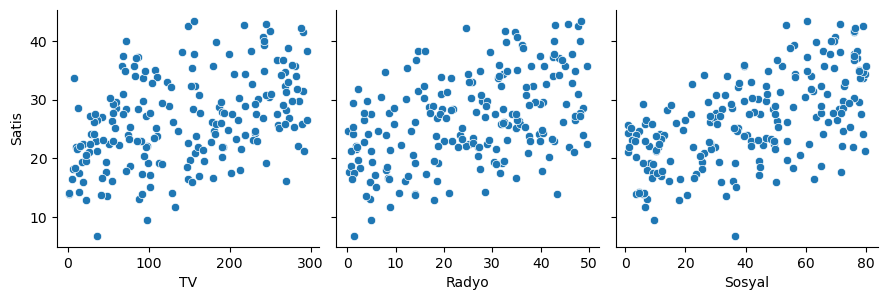

,count,mean,std,min,25%,50%,75%,max
TV,200.0,145.201870,88.467429,1.656635,68.574724,148.345876,227.057885,296.066081
Radyo,200.0,25.218757,14.650060,0.253079,13.073125,27.081994,37.109966,49.525257
Sosyal,200.0,41.653823,24.584704,0.867012,20.441625,42.031958,64.889191,79.977414
Satis,200.0,26.525977,7.604660,6.768209,21.505461,26.213765,31.880847,43.522939


In [6]:
# Keşifsel Analiz (EDA)

import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df, x_vars=["TV", "Radyo", "Sosyal"], y_vars="Satis", height=3)
plt.show()

df.describe().T

In [12]:
import statsmodels.api as sm

X = df[["TV", "Radyo", "Sosyal"]]
y = df["Satis"]

# Sabit terim (intercept) ekleniyor
X_const = sm.add_constant(X)

model = sm.OLS(y, X_const).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  Satis   R-squared:                       0.841
Model:                            OLS   Adj. R-squared:                  0.838
Method:                 Least Squares   F-statistic:                     345.2
Date:                Sat, 06 Dec 2025   Prob (F-statistic):           6.07e-78
Time:                        18:18:27   Log-Likelihood:                -505.23
No. Observations:                 200   AIC:                             1018.
Df Residuals:                     196   BIC:                             1032.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.8315      0.714      6.771      0.0

### 1. Üst Bilgiler

**Dep. Variable: Satis** - Bağımlı değişkenin adı. Bu modelde Satis değerleri tahmin ediliyor.

**Model: OLS** - Kullanılan yöntem: Ordinary Least Squares (En Küçük Kareler).

**Method: Least Squares** - Katsayılar, hata kareleri toplamını minimize edecek şekilde bulunmuştur.

**Date / Time** - Analizin yapıldığı tarih ve saat.

**No. Observations: 200** - Toplam gözlem sayısı: 200.

**Df Residuals: 196** - Residual (artık) serbestlik derecesi</br>
df_resid=n−p−1=200−3−1=196</br>
p -> bağımsız değişken sayısı.

**Df Model: 3** - Üç bağımsız değişken kullanılmış (TV, Radyo, Sosyal Medya).

**Covariance Type: nonrobust** - Klasik hata terimi varsayımlarına göre standart hatalar hesaplanmış.




### 2. Katsayı Tablosu (Coefficient Table)
| Değişken | coef | std err | t | P>|t| | 95% CI |</br>
|----------|------|---------|---|--------|---------|

**const (β₀ = 4.8315)** - Hiç reklam yapılmasa bile satışların ortalama 4.83 birim olacağı tahmin edilir.

**TV (β₁ = 0.0396)** - TV reklam bütçesi 1 birim arttığında, satışlar ortalama 0.0396 birim artar (diğer değişkenler sabitken).</br>
P-değeri = 0.000 → İstatistiksel olarak çok anlamlı.</br>
TV reklamı satış üzerinde gerçek ve güçlü bir etkiye sahip.

**Radyo (β₂ = 0.2849)** - Radyo bütçesi 1 birim arttığında, satış ortalama 0.2849 birim artıyor.</br>
P-değeri = 0.000 → Çok anlamlı bir değişken.</br>
Radyo reklamının TV’den daha yüksek katsayıya sahip olması - Bir birimlik bütçe artışının satışa etkisi daha büyük.

**Sosyal (β₃ = 0.2105)** - Sosyal medya reklam bütçesi 1 birim arttığında, satış ortalama 0.2105 birim artar.</br>
P-değeri = 0.000 → Çok anlamlı.

**std err** - Her katsayının tahmin belirsizliğidir. Ne kadar küçükse, katsayı o kadar güvenilirdir.

**t** - t ne kadar büyükse, katsayı o kadar anlamlıdır. </br>
* t değeri ne kadar büyükse:
  - p-değeri o kadar küçük olur
  - katsayının sıfır olma olasılığı o kadar düşer
  - değişken daha anlamlıdır


**[0.025, 0.975] (Güven aralığı)** - Her katsayının %95 güven aralığı.




### 3. Model Uyum Ölçümleri (Model Fit Metrics)

**R-squared = 0.841** - Model bağımlı değişkendeki varyansın %84.1'ini açıklıyor.

**Adj. R-squared = 0.838** - Gereksiz değişken eklenmesinden etkilenmez. 0.838 de oldukça yüksek. Model sağlam.

**F-statistic = 345.2** - Modeldeki tüm bağımsız değişkenlerin toplam etkisinin anlamlı olup olmadığını test eder.

**Prob (F-statistic) = 6.07e-78** </br>
F testinin p-değeri aşırı küçük. </br>
- Model genel olarak çok anlamlı.
- En az bir bağımsız değişken Y’yi açıklıyor.

**Durbin-Watson = 1.879** - DW ≈ 2 ise residual’larda otokorelasyon yoktur. </br>
- Otokorelasyon problemi görünmüyor.
- Hata terimleri bağımsız.

**Jarque-Bera (JB) = 0.740 ; Prob(JB) = 0.691** - JB testi residual’ların normal dağılıp dağılmadığını test eder. </br>
residual normalitesi testi. </br>
p > 0.05 → normal dağılıma uygun.

**Omnibus test = 0.785 ; Prob(Omnibus) = 0.675** - residual normalitesi testi. p > 0.05 → normal dağılıma uygun.

**Skew = 0.148** - Hataların simetrik olduğunu gösterir (skew ≈ 0 iyi).

**Kurtosis = 2.961** - Normal dağılımın kurtosis’i 3’tür. → 2.96 → normal dağılıma oldukça yakın.

**Cond. No. = 578** Bu, bağımsız değişkenler arasında multicollinearity olup olmadığını gösteren kaba bir ölçüdür. </br>
- 30–100 → hafif
- 100–1000 → orta
- 1000 → ciddi

578 → belirli düzeyde multicollinearity olabilir ama kritik değil.(VIF ile analiz edilebilir)

**Log-Likelihood: -505.23** - modelin gözlenen veriyi ne kadar iyi açıkladığını ölçen bir olasılık skorudur. Negatif olması normaldir — logaritma alınan ihtimaller çok küçük olduğu için.</br>

Burada elde edilen değer tek başına bir şey ifade etmez. Ancak farklı modelleri karşılaştırırken anlam kazanır. daha yüksek LL → daha iyi model

**AIC:1018** - AIC (Akaike Information Criterion).
- AIC=2k−2log(L) k: ahmin edilen parametre sayısı L:likelihood (olasılık)
- Modelin veriyi iyi açıklamasını ister (LL yüksek olsun)
- Ama çok fazla parametre kullanılmasına ceza verir (basit model ister)
- Daha küçük AIC = daha iyi model
- Bu yüzden AIC mutlak değer olarak değil, modeller arasında karşılaştırma için kullanılır.


**BIC:1032** - 3. BIC (Bayesian Information Criterion)
- BIC=kln(n)−2log(L)
- BIC, AIC’ye benzer ama parametre sayısına daha ağır ceza verir
- Özellikle fazla değişken içeren modelleri daha çok “uyarır”
- Daha küçük BIC = daha iyi model


**Bu model için:**
1. LL tek başına anlamlı değil → diğer modellerle karşılaştırınca anlam kazanacak
2. AIC ve BIC — modelin karmaşıklık + açıklama gücü dengesi
3. AIC < BIC olduğu için model makul düzeyde karmaşık
4. Başka modellerle karşılaştırınca işe yarayacak

**AIC vs BIC: Hangisini kullanmalı**</br>

| Ölçüt   | Ne ister?                                  | Ne zaman kullanılır?                     |
| ------- | ------------------------------------------ | ---------------------------------------- |
| **AIC** | Tahmin hatasını minimize eden modeli seçer | Makine öğrenmesi, tahmin problemleri     |
| **BIC** | Gerçek modeli bulmayı amaçlar              | Ekonometrik modelleme, bilimsel açıklama |

**Özet**
- Log-Likelihood modelin veriyi ne kadar iyi açıkladığını ölçer (yüksek → iyi).
- AIC açıklama gücü + basitlik dengesini ölçer (düşük → iyi).
- BIC AIC’ye benzer ama gereksiz değişkene daha fazla ceza verir (düşük → iyi).
- Bu değerler modelleri karşılaştırmak için kullanılır; tek başlarına anlamlı değildir.

  

In [14]:
# Artıkların (Residuals) Hesaplanması
df["y_pred"] = model.predict(X_const)
df["residuals"] = df["Satis"] - df["y_pred"]
df

,TV,Radyo,Sosyal,Satis,y_pred,residuals
0,112.362036,32.101582,8.249910,19.184165,20.156730,-0.972565
1,285.214292,4.206998,72.204233,29.732899,32.508621,-2.775722
2,219.598183,8.081436,40.420190,23.971305,24.326987,-0.355682
3,179.597545,44.927709,66.116597,35.779807,38.649864,-2.870057
4,46.805592,30.321453,25.603968,19.428505,20.709543,-1.281037
...,...,...,...,...,...,...
195,104.762872,46.537866,37.916931,32.823880,30.213064,2.610816
196,217.786704,42.920638,53.404619,42.815452,36.912875,5.902576
197,269.133078,21.449701,13.785590,28.337047,24.488133,3.848914
198,266.125927,37.543553,15.383122,29.178061,29.290040,-0.111979


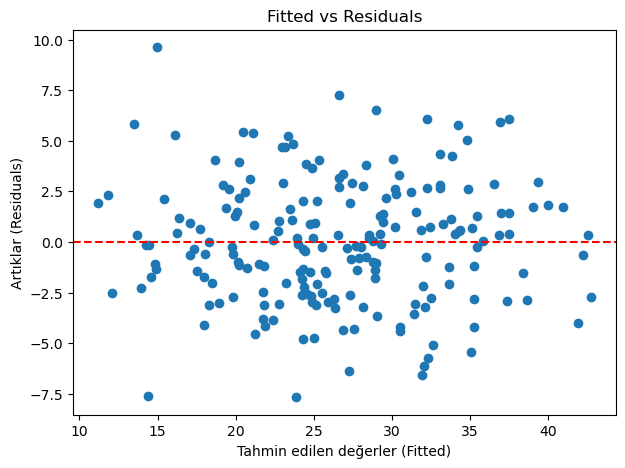

In [16]:
# Lineerlik Varsayımı – Fitted vs Residual Plot

plt.figure(figsize=(7,5))
plt.scatter(df["y_pred"], df["residuals"])
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Tahmin edilen değerler (Fitted)")
plt.ylabel("Artıklar (Residuals)")
plt.title("Fitted vs Residuals")
plt.show()

# Noktalar 0 etrafında rastgele dağılmışsa → lineerlik ve hataların ortalaması ≈ 0 varsayımı makul.
# Desen (yay, U, ters U, fan şekli) varsa model formu veya homoskedastisite sorun olabilir.

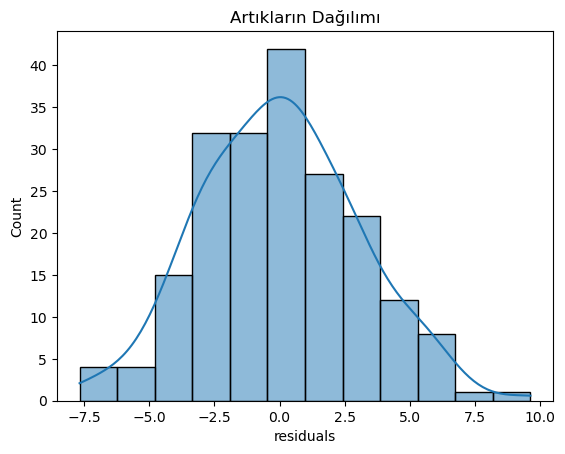

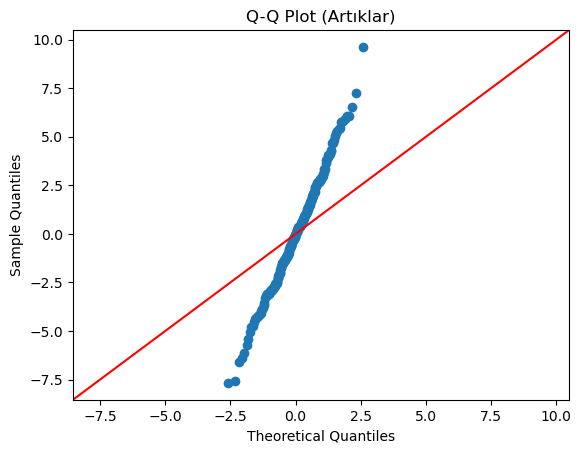

In [17]:
# Normal Dağılım Varsayımı – Histogram + Q-Q Plot

# Histogram + KDE
sns.histplot(df["residuals"], kde=True)
plt.title("Artıkların Dağılımı")
plt.show()

# Q-Q Plot
sm.qqplot(df["residuals"], line="45")
plt.title("Q-Q Plot (Artıklar)")
plt.show()


In [19]:
# Homoskedastisite – Breusch-Pagan Testi

from statsmodels.stats.diagnostic import het_breuschpagan

resid = df["residuals"]
bp_test = het_breuschpagan(resid, X_const)

bp_labels = ["LM Stat", "LM p-value", "F-Stat", "F p-value"]
dict(zip(bp_labels, bp_test))

# LM p-value veya F p-value < 0.05 → heteroskedastisite olabilir.
# p-value > 0.05 → homoskedastisite varsayımını reddetmiyoruz (yani kabul edilebilir).

{'LM Stat': 1.5324580357720219,
 'LM p-value': 0.674799546671413,
 'F-Stat': 0.504468341168277,
 'F p-value': 0.6796354238596474}

In [20]:
# Bağımsızlık Varsayımı – Durbin-Watson

from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(df["residuals"])
dw

# DW ≈ 2 → otokorelasyon yok (iyi).
# 0’a yakın → pozitif otokorelasyon
# 4’e yakın → negatif otokorelasyon

1.8792820018127374

In [23]:
# Multicollinearity – VIF (Variance Inflation Factor)

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i)
                   for i in range(X_const.shape[1])]

vif_data

# VIF ≈ 1–5 → sorun yok
# VIF > 10 → ciddi multicollinearity şüphesi
# Intercept’in VIF’i genellikle yorumlanmaz.

,feature,VIF
0,const,10.899557
1,TV,1.003229
2,Radyo,1.016680
3,Sosyal,1.018122


In [22]:
X_const.shape

(200, 4)

variance_inflation_factor(X_const.values, i)
- inci sütunu bağımlı değişken olarak seçer
- diğer sütunları bağımsız değişken olarak alır
- regresyon kurar
- R² hesaplar
- sonra VIF’i hesaplar

$ \text{VIF}_j = \frac{1}{1 - R_j^2} $

